# 長條圖 Bar Plot：比較生活選擇，把錢、時間與數量看清楚

月底明明沒買什麼，錢為什麼不見了？雞蛋大盒一定比較便宜嗎？團購便當要訂幾份？外送貴的是餐點還是附加費？哪家早餐店「通常」比較快，又會不會偶爾等很久？

## 第一部分：Matplotlib

### 範例：第一張早餐銷量長條圖

範例檔：[01_第一張早餐銷量長條圖.py](./Data_Visualization_src/bar_plot_examples/01_第一張早餐銷量長條圖.py)

早餐店老闆想知道明天備料該先注意哪些品項。先用程式內的五筆數字，練習把品項與份數一一配對。


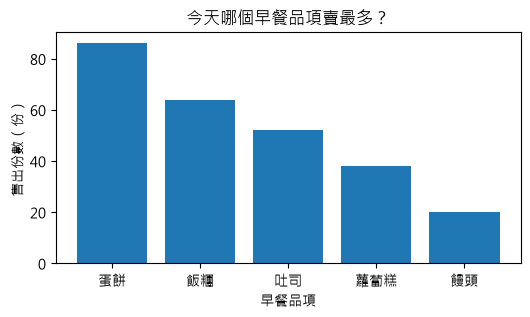

這五種品項合計： 260 份


In [ ]:
import matplotlib.pyplot as plt

items = ["蛋餅", "飯糰", "吐司", "蘿蔔糕", "饅頭"]
sales = [86, 64, 52, 38, 20]

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(6, 3))
	ax.bar(items, sales)
	ax.set(title="今天哪個早餐品項賣最多？", xlabel="早餐品項", ylabel="售出份數（份）")
	ax.set_ylim(bottom=0)
	plt.show()

print("這五種品項合計：", sum(sales), "份")


### 範例：長條寬度與數值標籤

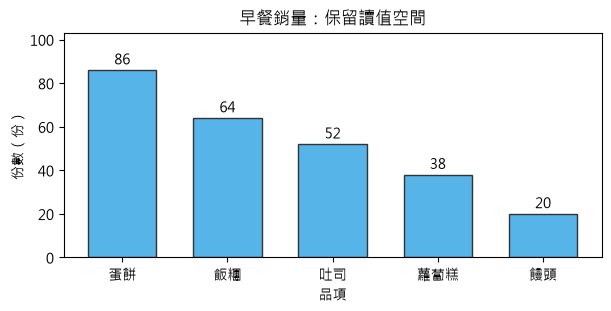

In [ ]:
import matplotlib.pyplot as plt

items = ["蛋餅", "飯糰", "吐司", "蘿蔔糕", "饅頭"]
sales = [86, 64, 52, 38, 20]

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")
	bars = ax.bar(df["品項"], df["份數"], width=0.65, color="#56B4E9", edgecolor="#333333")
	ax.bar_label(bars, fmt="%.0f", padding=3)
	ax.set(title="早餐銷量：保留讀值空間", xlabel="品項", ylabel="份數（份）")
	ax.set_ylim(0, df["份數"].max() * 1.2)
	plt.show()


### 範例：橫向長條讀懂每月支出

範例檔："./Data_Visualization_data/租屋族每月支出.csv"

In [3]:
import pandas as pd

df = pd.read_csv("./bar_plot_data/租屋族每月支出.csv", encoding="utf-8-sig")
df

,項目,金額
0,房租與管理費,9500
1,三餐與食材,7200
2,大眾運輸與共享單車,1280
3,水電瓦斯,1150
4,手機月租,599
5,休閒娛樂,1500
6,生活用品,800
7,手搖飲與咖啡,1350


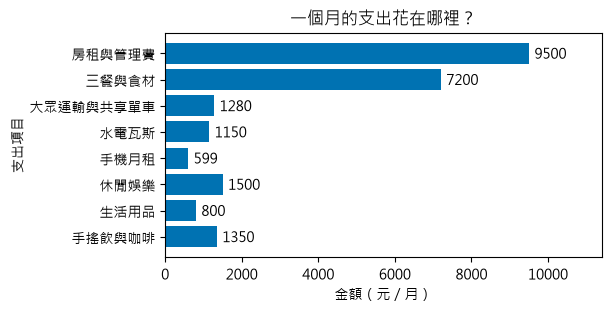

In [ ]:
import matplotlib.pyplot as plt

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(6, 3), layout="constrained")
	bars = ax.barh(df["項目"], df["金額"], color="#0072B2")
	ax.invert_yaxis()
	ax.bar_label(bars, fmt="%.0f", padding=4)
	ax.set(title="一個月的支出花在哪裡？", xlabel="金額（元／月）", ylabel="支出項目")
	ax.set_xlim(0, df["金額"].max() * 1.2)
	plt.show()


### 範例：零點基準與截斷座標


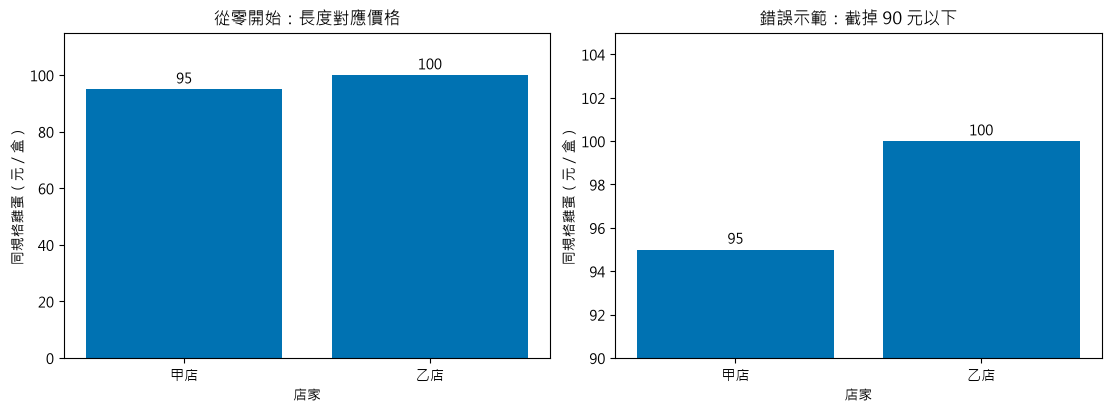

乙比甲貴 5 元；約 5.3 %


In [ ]:
import matplotlib.pyplot as plt

stores, prices = ["甲店", "乙店"], [95, 100]

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
	for ax in axes:
		bars = ax.bar(stores, prices, color="#0072B2")
		ax.bar_label(bars, padding=3)
		ax.set(ylabel="同規格雞蛋（元／盒）", xlabel="店家")
	axes[0].set(title="從零開始：長度對應價格", ylim=(0, 115))
	axes[1].set(title="錯誤示範：截掉 90 元以下", ylim=(90, 105))
	plt.show()
print("乙比甲貴", 100 - 95, "元；約", round((100 / 95 - 1) * 100, 1), "%")


### 範例：顏色強調與黑白列印

範例檔："./bar_plot_data/早餐店品項銷量.csv"。把最高銷量標出來，不需要讓每根都變成搶眼顏色。


In [6]:
import pandas as pd

df = pd.read_csv("./bar_plot_data/早餐店品項銷量.csv", encoding="utf-8-sig")
df

,品項,份數
0,蛋餅,86
1,飯糰,64
2,吐司,52
3,蘿蔔糕,38
4,饅頭,20


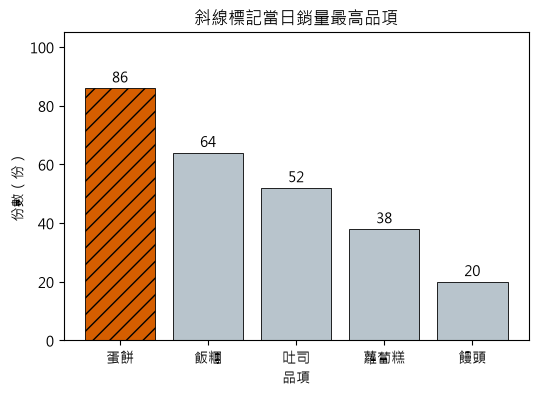

In [ ]:
import matplotlib.pyplot as plt

stores, prices = ["甲店", "乙店"], [95, 100]

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	is_top = df["份數"] == df["份數"].max()
	colors = ["#D55E00" if flag else "#B8C4CC" for flag in is_top]
	fig, ax = plt.subplots(figsize=(6, 4))
	bars = ax.bar(df["品項"], df["份數"], color=colors, edgecolor="black", linewidth=0.6)
	for bar, flag in zip(bars, is_top):
		if flag:
			bar.set_hatch("//")
	ax.bar_label(bars, padding=3)
	ax.set(title="斜線標記當日銷量最高品項", xlabel="品項", ylabel="份數（份）", ylim=(0, 105))
	plt.show()

### 範例：通勤調查先計數再畫圖

範例檔："./bar_plot_data/同學通勤單選調查.csv"。一人一列、每人只能選一種方式，先數每個類別的人數。


In [11]:
import pandas as pd

df = pd.read_csv("./bar_plot_data/同學通勤單選調查.csv", encoding="utf-8-sig")
counts = df["主要方式"].value_counts()
print(counts)
df.head()

主要方式
捷運     10
機車      8
公車      6
步行      4
自行車     2
Name: count, dtype: int64


,同學編號,主要方式
0,S01,捷運
1,S02,捷運
2,S03,捷運
3,S04,捷運
4,S05,捷運


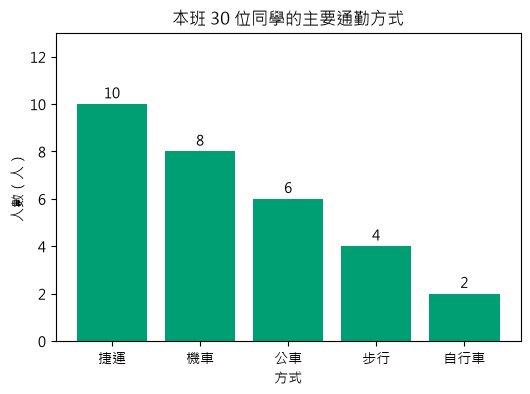

In [ ]:
import matplotlib.pyplot as plt

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(6, 4))
	bars = ax.bar(counts.index, counts.values, color="#009E73")
	ax.bar_label(bars, padding=3)
	ax.set(title=f"本班 {len(df)} 位同學的主要通勤方式", xlabel="方式", ylabel="人數（人）")
	ax.set_ylim(0, counts.max() + 3)
	plt.show()


### 範例：預算與實際並排比較

範例檔："./bar_plot_data/預算與實際支出.csv"。月底檢查哪幾類超過自己訂的預算。

In [14]:
import pandas as pd

df = pd.read_csv("./bar_plot_data/預算與實際支出.csv", encoding="utf-8-sig")
df

,項目,預算,實際
0,房租,9000,9000
1,餐費,6000,6800
2,交通,1500,1280
3,飲料,800,1350
4,娛樂,1500,900
5,用品,1000,1200


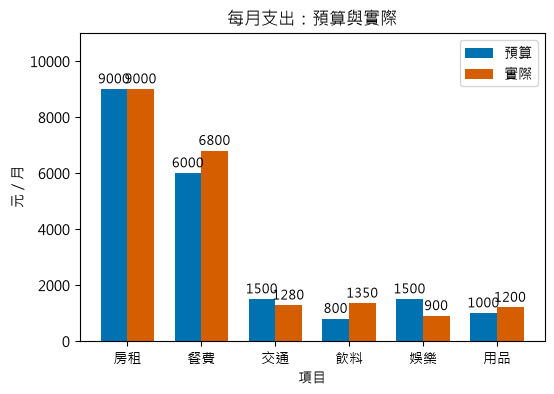

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	x = np.arange(len(df))
	width = 0.36
	fig, ax = plt.subplots(figsize=(6, 4))
	planned = ax.bar(x - width / 2, df["預算"], width=width, label="預算", color="#0072B2")
	actual = ax.bar(x + width / 2, df["實際"], width=width, label="實際", color="#D55E00")
	ax.set_xticks(x, df["項目"])
	ax.bar_label(planned, padding=3, fontsize=9)
	ax.bar_label(actual, padding=3, fontsize=9)
	ax.set(title="每月支出：預算與實際", xlabel="項目", ylabel="元／月", ylim=(0, 11000))
	ax.legend()
	plt.show()


### 範例：三種午餐方式的群組位置

範例檔："./bar_plot_data/一週午餐三種方式.csv"。五個平日，每天比較自備、店內、外送三個情境。


In [16]:
import pandas as pd

df = pd.read_csv("./bar_plot_data/一週午餐三種方式.csv", encoding="utf-8-sig")
df

,星期,自備便當,店內購買,外送到家
0,一,55,100,160
1,二,60,110,180
2,三,50,95,155
3,四,65,120,190
4,五,60,105,170


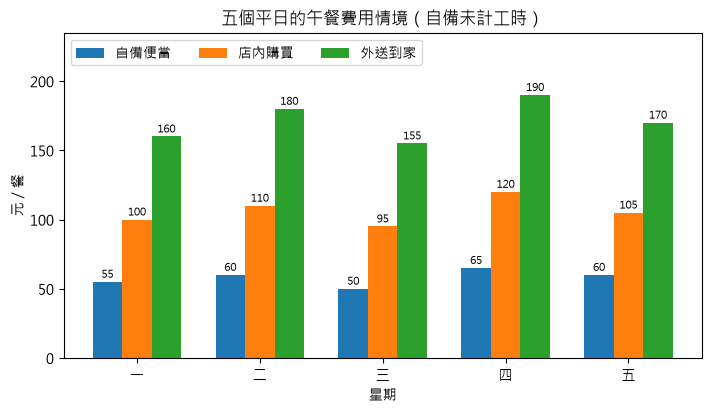

In [ ]:
import matplotlib.pyplot as plt

methods = ["自備便當", "店內購買", "外送到家"]

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	x = np.arange(len(df))
	width = 0.24
	fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
	for i, method in enumerate(methods):
		offset = (i - (len(methods) - 1) / 2) * width
		bars = ax.bar(x + offset, df[method], width=width, label=method)
		ax.bar_label(bars, padding=2, fontsize=8)
	ax.set_xticks(x, df["星期"])
	ax.set(title="五個平日的午餐費用情境（自備未計工時）", xlabel="星期", ylabel="元／餐", ylim=(0, 235))
	ax.legend(ncols=3, loc="upper left")
	plt.show()


### 範例：雞蛋盒價與每顆單價

範例檔："./bar_plot_data/超市雞蛋包裝比價.csv"。不同包裝看盒價不公平，先換成每顆同單位再比較。


In [22]:
import pandas as pd

df = pd.read_csv("./bar_plot_data/超市雞蛋包裝比價.csv", encoding="utf-8-sig")
df["每顆單價"] = df["盒價"] / df["顆數"]
df

,商品,盒價,顆數,每顆單價
0,甲牌十入,75,10,7.5
1,乙牌十二入,84,12,7.0
2,丙牌六入,48,6,8.0
3,丁牌十五入,108,15,7.2


In [ ]:
import matplotlib.pyplot as plt

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(6, 4))
	

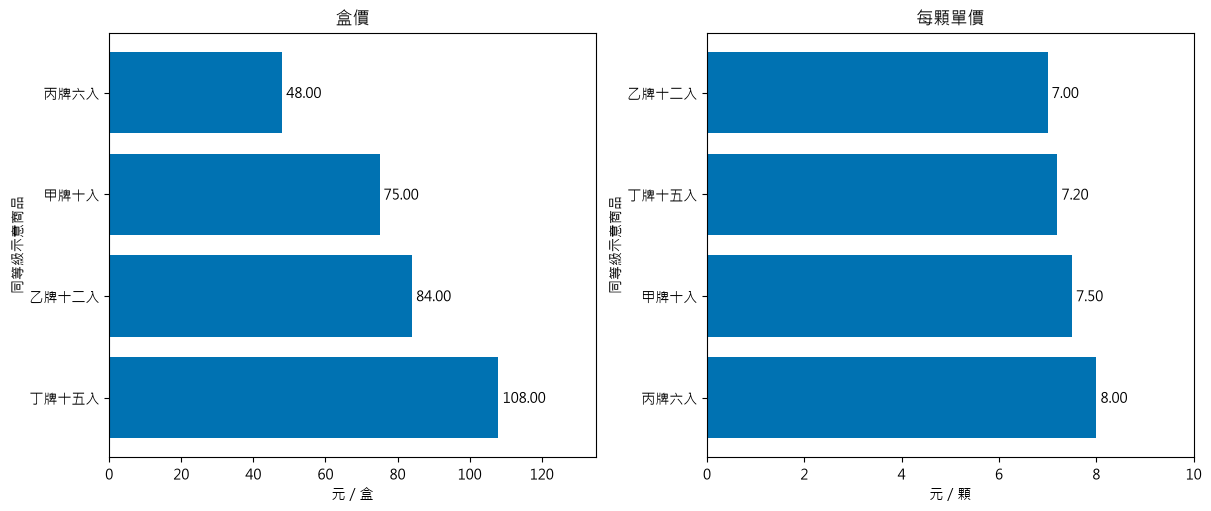

In [ ]:
import matplotlib.pyplot as plt

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
	for ax, column, unit in zip(axes, ["盒價", "每顆單價"], ["元／盒", "元／顆"]):
		ranked = df.sort_values(column)
		bars = ax.barh(ranked["商品"], ranked[column], color="#0072B2")
		ax.invert_yaxis()
		ax.bar_label(bars, fmt="%.2f", padding=3)
		ax.set(title=column, xlabel=unit, ylabel="同等級示意商品")
		ax.set_xlim(0, ranked[column].max() * 1.25)
	plt.show()


## 第二部分：使用 Seaborn 

### 範例：Seaborn第一張早餐長條圖

In [24]:
import pandas as pd

df = pd.read_csv("./bar_plot_data/早餐店品項銷量.csv", encoding="utf-8-sig")
df

,品項,份數
0,蛋餅,86
1,飯糰,64
2,吐司,52
3,蘿蔔糕,38
4,饅頭,20


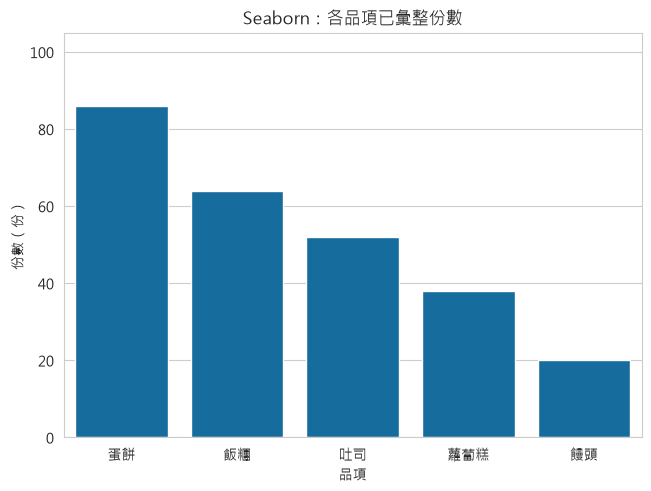

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = fig, ax = plt.subplots(sharex=True, layout="constrained")
	sns.barplot(data=df, x="品項", y="份數", estimator="sum", errorbar=None, color="#0072B2", ax=ax)
	ax.set(title="Seaborn：各品項已彙整份數", xlabel="品項", ylabel="份數（份）", ylim=(0, 105))
	plt.show()

### 範例：午餐寬表轉長表

範例檔："./bar_plot_data/一週午餐三種方式.csv"。把三種方式的欄位往下接，交給 hue 自動安排並排。


In [26]:
import pandas as pd

df = pd.read_csv("./bar_plot_data/一週午餐三種方式.csv", encoding="utf-8-sig")
df

,星期,自備便當,店內購買,外送到家
0,一,55,100,160
1,二,60,110,180
2,三,50,95,155
3,四,65,120,190
4,五,60,105,170


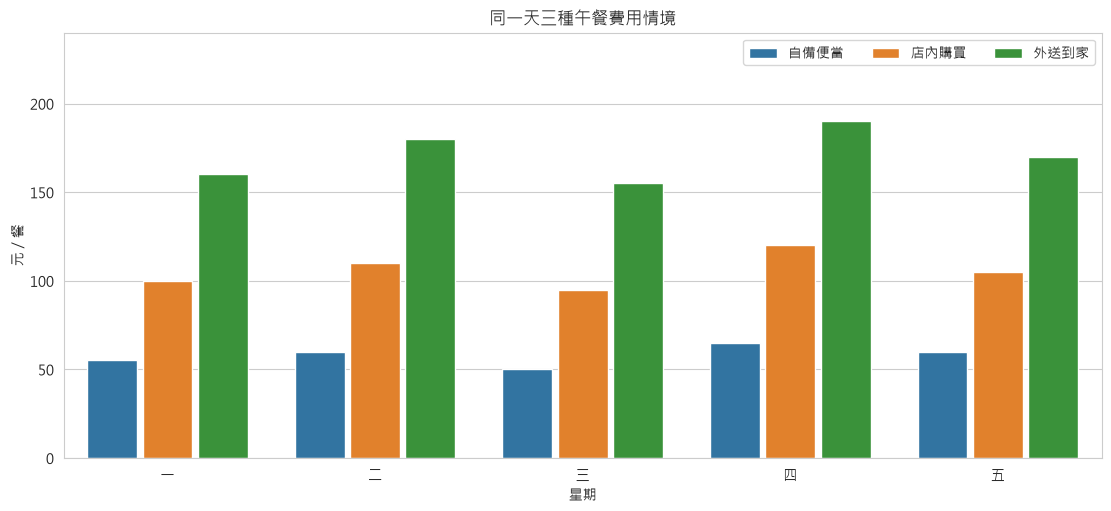

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

methods = ["自備便當", "店內購買", "外送到家"]
long = df.melt(id_vars="星期", value_vars=methods, var_name="方式", value_name="費用")

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
	sns.barplot(data=long, x="星期", y="費用", hue="方式", order=["一", "二", "三", "四", "五"],
				hue_order=methods, estimator="sum", errorbar=None, gap=0.1, ax=ax)
	ax.set(title="同一天三種午餐費用情境", xlabel="星期", ylabel="元／餐", ylim=(0, 240))
	ax.legend(ncols=3)
	plt.show()

### 範例：固定配色比較預算狀態



範例檔："./bar_plot_data/預算與實際支出.csv"

整份報告中「預算」固定藍色，「實際」固定橘色，方便學生追蹤。


In [28]:
import pandas as pd

df = pd.read_csv("./bar_plot_data/預算與實際支出.csv", encoding="utf-8-sig")
df

,項目,預算,實際
0,房租,9000,9000
1,餐費,6000,6800
2,交通,1500,1280
3,飲料,800,1350
4,娛樂,1500,900
5,用品,1000,1200


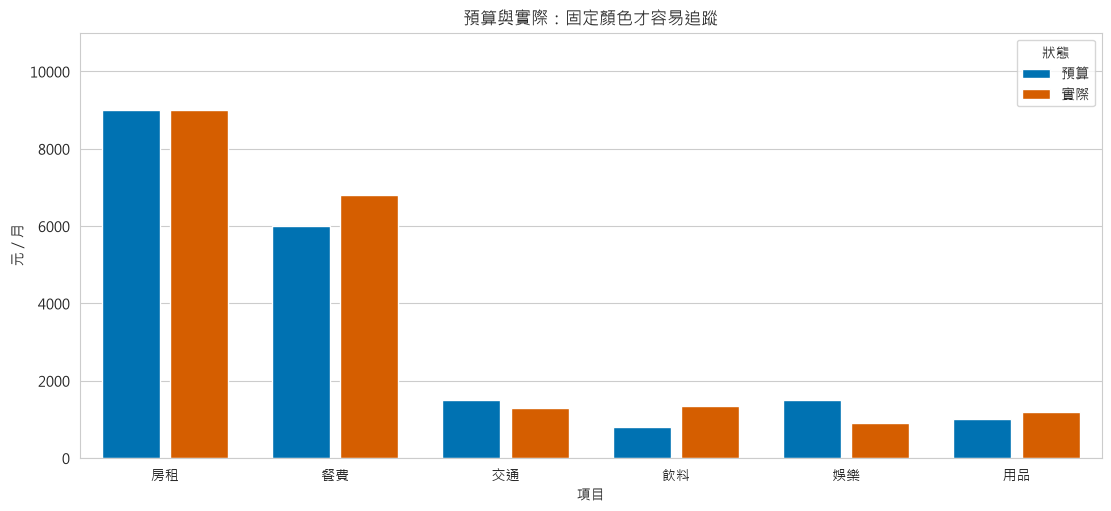

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常

	long = df.melt(id_vars="項目", value_vars=["預算", "實際"], var_name="狀態", value_name="金額")
	palette = {"預算": "#0072B2", "實際": "#D55E00"}
	
	fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
	sns.barplot(data=long, x="項目", y="金額", hue="狀態", hue_order=["預算", "實際"],
				order=df["項目"].tolist(), palette=palette, saturation=1, estimator="sum", errorbar=None, gap=0.15, ax=ax)
	ax.set(title="預算與實際：固定顏色才容易追蹤", xlabel="項目", ylabel="元／月", ylim=(0, 11000))
	plt.show()


### 範例 25｜等候時間的SD與CI



範例檔："./bar_plot_data/早餐店等候紀錄.csv"

左圖說明個體分散，右圖示範平均估計區間，兩張圖平均高度相同。


In [31]:
import pandas as pd

df = pd.read_csv("./bar_plot_data/早餐店等候紀錄.csv", encoding="utf-8-sig")
df.head()

,顧客編號,店家,等候分鐘
0,W001,巷口早餐店,3
1,W002,巷口早餐店,4
2,W003,巷口早餐店,4
3,W004,巷口早餐店,5
4,W005,巷口早餐店,5


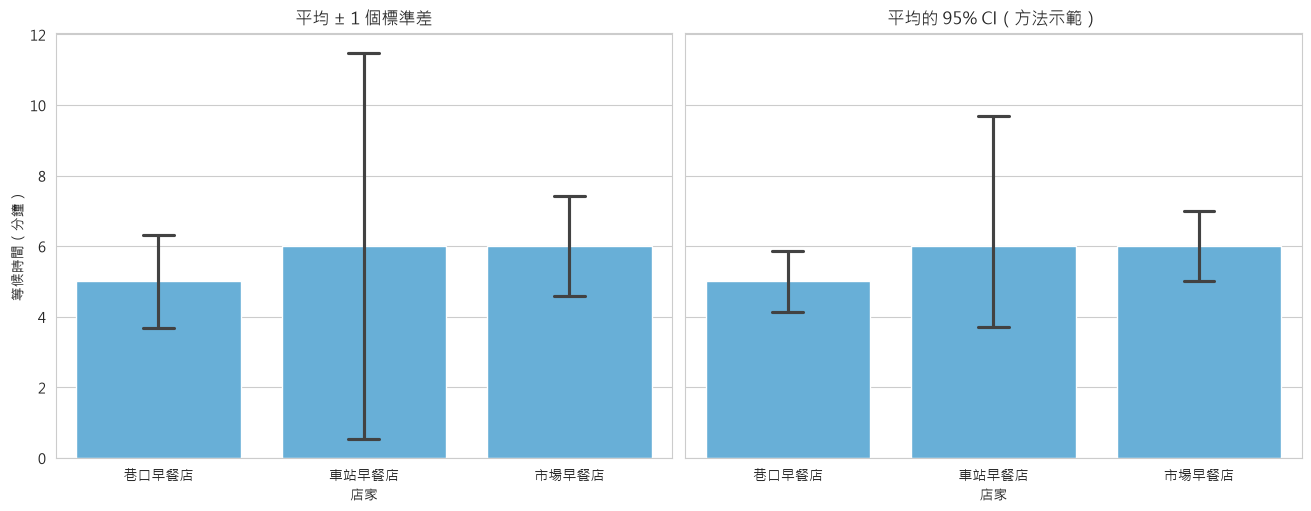

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["巷口早餐店", "車站早餐店", "市場早餐店"]

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, layout="constrained")
	sns.barplot(data=df, x="店家", y="等候分鐘", order=order, estimator="mean", errorbar="sd", capsize=0.15, color="#56B4E9", ax=axes[0])
	sns.barplot(data=df, x="店家", y="等候分鐘", order=order, estimator="mean", errorbar=("ci", 95), seed=42,
				n_boot=2000, capsize=0.15, color="#56B4E9", ax=axes[1])
	axes[0].set_title("平均 ± 1 個標準差")
	axes[1].set_title("平均的 95% CI（方法示範）")
	for ax in axes:
		ax.set(xlabel="店家", ylabel="等候時間（分鐘）")
	plt.show()

### 範例：分店平假日先換成每日平均



範例檔："./bar_plot_data/早餐分店一週銷量.csv"

平日有五天、假日兩天，直接比總量會受到營業天數影響。


In [37]:
import pandas as pd

df = pd.read_csv("./bar_plot_data/早餐分店一週銷量.csv", encoding="utf-8-sig")
df.head()

daily = df.groupby(["日期", "日別", "分店"], as_index=False)["份數"].sum()
summary = daily.groupby(["分店", "日別"], as_index=False).agg(每日平均=("份數", "mean"), 營業天數=("日期", "nunique"))
print(daily.head())
print(summary.head())

           日期  日別   分店   份數
0  2026-04-06  平日  住宅店  111
1  2026-04-06  平日  市場店  103
2  2026-04-06  平日  車站店   93
3  2026-04-07  平日  住宅店   99
4  2026-04-07  平日  市場店  117
    分店  日別   每日平均  營業天數
0  住宅店  假日  121.0     2
1  住宅店  平日  107.8     5
2  市場店  假日  139.0     2
3  市場店  平日  110.2     5
4  車站店  假日   92.0     2


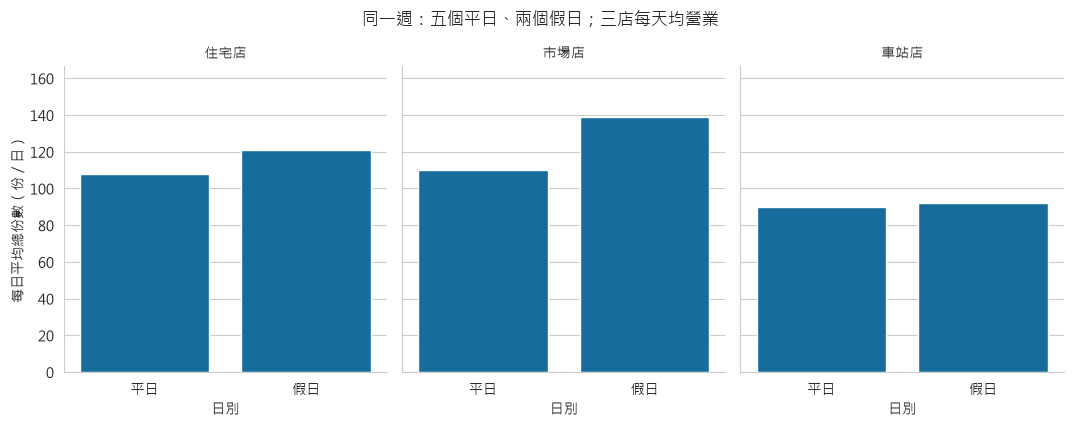

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	# 繪製分店比較圖
	g = sns.catplot(
			data=summary,
			x="日別",
			y="每日平均",
			col="分店",
			kind="bar",
			order=["平日", "假日"],
			errorbar=None,
			color="#0072B2",
			height=4,
			aspect=0.9,
			sharey=True
		)
	g.set_axis_labels("日別", "每日平均總份數（份／日）") # 設定座標軸標題
	g.set_titles("{col_name}") # 每張子圖使用分店名稱當標題
	for ax in g.axes.flat: ax.set_ylim(0, summary["每日平均"].max() * 1.2) # 統一 Y 軸範圍
	g.figure.suptitle("同一週：五個平日、兩個假日；三店每天均營業", y=1.05)
	plt.show()

### 範例：滿意度次數與百分比結構

範例檔："./bar_plot_data/便當店滿意度次數.csv"

三店回覆人數不同，先保留等級順序，再換成各店內部百分比。


In [41]:
import pandas as pd

df = pd.read_csv("./bar_plot_data/便當店滿意度次數.csv", encoding="utf-8-sig")
df

,店家,非常不滿意,不滿意,普通,滿意,非常滿意
0,甲店,2,3,5,12,8
1,乙店,1,2,4,7,6
2,丙店,3,4,8,15,10


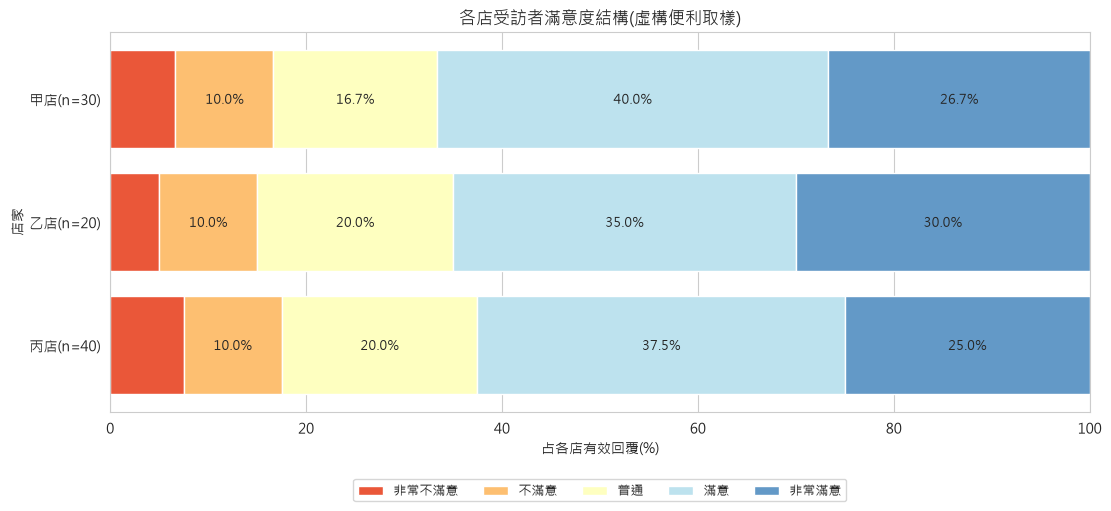

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


### 設定滿意度等級
levels = ["非常不滿意", "不滿意", "普通", "滿意", "非常滿意"] # 設定滿意度由低到高的五個等級

### 計算各店滿意度比例
totals = df[levels].sum(axis=1) # 將每間店五種滿意度的人數加總，得到各店有效回覆總人數
percent = df[levels].div(totals, axis=0) * 100 # 每個滿意度人數除以該店總人數，轉換成百分比


### 繪製百分比堆疊長條圖
with sns.axes_style("whitegrid"): # 套用 Seaborn 白底格線樣式
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 使用微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常

    colors = sns.color_palette("RdYlBu", n_colors=5) # 從 RdYlBu 色盤取得 5 種顏色，分別代表五種滿意度

    fig, ax = plt.subplots(figsize=(11, 5), layout="constrained") # 建立 11 × 5 吋的圖表

    left = np.zeros(len(df)) # 建立每間店的堆疊起始位置，一開始全部從 0 開始

    for level, color in zip(levels, colors): # 依序取得滿意度等級及其對應顏色
        values = percent[level].to_numpy() # 取得目前滿意度等級在各店所占的百分比
        bars = ax.barh(df["店家"], values, left=left, label=level, color=color) # 繪製水平長條，並從上一段結束的位置繼續堆疊
        ax.bar_label(bars, labels=[f"{v:.1f}%" if v >= 9 else "" for v in values], label_type="center", fontsize=9) # 百分比至少 9% 才在長條中央顯示數值
        left += values # 將目前百分比累加，作為下一個滿意度區塊的起始位置

    ax.set_yticks(np.arange(len(df)), [f"{shop}(n={n})" for shop, n in zip(df["店家"], totals)]) # Y 軸顯示店家名稱與該店有效回覆人數
    ax.invert_yaxis() # 反轉 Y 軸，讓第一間店顯示在最上方
    ax.set(title="各店受訪者滿意度結構(虛構便利取樣)", xlabel="占各店有效回覆(%)", ylabel="店家", xlim=(0, 100)) # 設定標題、座標軸名稱與 X 軸範圍
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncols=5, fontsize=9) # 將圖例放到圖表下方並排列成 5 欄

    plt.show() # 顯示圖表